## Oppgave 2

Denne delen består av tre deler:

- **2a:** Partikkelfordeling uten frastøtning
- **2b:** Partikkelfordeling med frastøtning
- **2c:** Effekt av lav temperatur \($\beta k$ = 1 vs $\beta k$ = 1000\)

In [799]:
#INITIALISERING

#importering
import numpy as np
from matplotlib import pyplot as plt

#konstanter
params_oppave_2 = {
"beta_k"                : 1,
"antallPartikler"       : 101,
"antallSimulasjoner"    : 100,
"timeSteps"             : 200
}

In [800]:
#HJELPEFUNKSJONER

def lag_prob_tabeller(params):
    beta_k = params["beta_k"]

    #siden potensialfunksjonene er så simple finner vi at p_pos og p_neg er konstante for både V1 og V2 (altså uavhengig av x)
    prob_tabell_V_i = {
    "p_pos" : 1/3,
    "p_neg" : 1/3
    }

    prob_tabell_V_ii = {
    "p_pos" : 1/(1 + np.exp(-2*beta_k) + np.exp(-beta_k)),
    "p_neg" : np.exp(-2*beta_k) / (                          #må skrives slik for å ikke få overflow
        np.exp(-2*beta_k) + 1 + np.exp(-beta_k)
    )
    }
    return prob_tabell_V_i, prob_tabell_V_ii

In [801]:
#SIMULERINGSFUNKSJONER

#Oppgave 2a simulering
def particleWalk_uten_Repulsion_sim(prob_tabell, params):                           #kan være forskjellig potensialfunksjon
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    p_pos = prob_tabell["p_pos"]
    p_neg = prob_tabell["p_neg"]

    partiklerPos = np.arange(0,antallPartikler)
    for _ in range(timeSteps):
        for i in range(len(partiklerPos)):
            tilfeldigtall = np.random.rand()

            if tilfeldigtall <= p_neg:
                partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos):
                partiklerPos[i] += 1

    return partiklerPos

#Oppgave 2b simulering
def particleWalk_med_Repulsion_sim(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    p_pos = prob_tabell["p_pos"]
    p_neg = prob_tabell["p_neg"]

    partiklerPos = np.arange(0,antallPartikler)
    partiklerPos_set = set(partiklerPos)

    for _ in range(timeSteps):
        tilfeldigRekkefølge = np.arange(0,antallPartikler)
        np.random.shuffle(tilfeldigRekkefølge)
        for i in tilfeldigRekkefølge:
            tilfeldigtall = np.random.rand()


            if tilfeldigtall <= p_neg:
                if (partiklerPos[i]-1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]-1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos):
                if (partiklerPos[i]+1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]+1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] += 1

    return partiklerPos

In [802]:
#OPPGAVEFUNKSJONER

#Oppgave 2a
def oppgave_2a(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    antallSimulasjoner = params["antallSimulasjoner"]

    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = particleWalk_uten_Repulsion_sim(prob_tabell, params)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 0

    averageDist = totalPartikler/antallSimulasjoner
    x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)

    return x_aksen, averageDist


#Oppgave 2b
def oppgave_2b(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    antallSimulasjoner = params["antallSimulasjoner"]
    

    totalPartikler = np.zeros(antallPartikler+2*timeSteps)         
    for i in range(antallSimulasjoner): 
        enSim = particleWalk_med_Repulsion_sim(prob_tabell, params)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             

    averageDist = totalPartikler/antallSimulasjoner
    x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)

    return x_aksen, averageDist

In [803]:
#Plottefunksjoner

#oppgave 2a og 2b
def plot_oppgave_2_a_b(oppgave, params, tittel):
    prob_tabell_V_i, prob_tabell_V_ii = lag_prob_tabeller(params)
    x_aksen_i, averageDist_i = oppgave(prob_tabell_V_i, params)
    x_aksen_ii, averageDist_ii = oppgave(prob_tabell_V_ii, params)

    plt.figure(figsize=(8,5))

    plt.plot(x_aksen_i, averageDist_i, label="$V(x)=k$")
    plt.plot(x_aksen_ii, averageDist_ii, label="$V(x)=-kx$")

    plt.xlabel("posisjon i $x$-retning")
    plt.ylabel("gjennomsnittlig antall partikler")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.title(tittel)

    plt.show()

#oppgave 2c
def plot_2c(params, beta_k_lowT=1000):

    params_lowT = params.copy()
    params_lowT["beta_k"] = beta_k_lowT

    _, V_ii = lag_prob_tabeller(params)
    _, V_ii_lowT = lag_prob_tabeller(params_lowT)

    x_a1, y_a1 = oppgave_2a(V_ii, params)
    x_a2, y_a2 = oppgave_2a(V_ii_lowT, params_lowT)

    x_b1, y_b1 = oppgave_2b(V_ii, params)
    x_b2, y_b2 = oppgave_2b(V_ii_lowT, params_lowT)

    fig, ax = plt.subplots(1,2, figsize=(12,4))


    ax[0].plot(x_a1, y_a1, color="C0", label=r"$\beta k=1$")
    ax[0].plot(x_a2, y_a2, color="C1", label=rf"$\beta k={beta_k_lowT}$")
    ax[0].set_title("2a(ii): V(x)=-kx")

    ax[1].bar(x_b1, y_b1, width=1, color="C0", alpha=0.6, label=r"$\beta k=1$")
    ax[1].bar(x_b2, y_b2, width=1, color="C1", alpha=0.6, label=rf"$\beta k={beta_k_lowT}$")
    ax[1].set_title("2b(ii): V(x)=-kx")

    for a in ax:
        a.set_xlabel("posisjon x")
        a.set_ylabel("gjennomsnittlig antall partikler")
        a.grid(alpha=0.3)
        a.legend()
        a.set_xlim(0,300)

    plt.tight_layout()
    plt.show()

### Oppgave 2a)

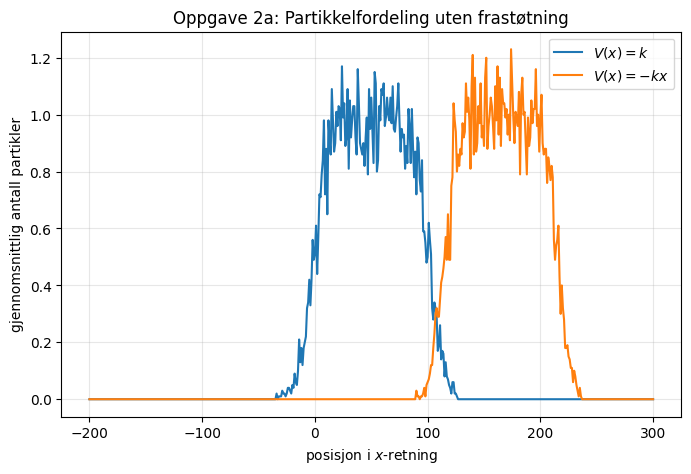

In [804]:
plot_oppgave_2_a_b(oppgave_2a, params_oppave_2, 
                  "Oppgave 2a: Partikkelfordeling uten frastøtning")

Figuren viser hvordan partikler uten frastøtning er gjennomsnittlig fordelt etter $100$ simulasjoner. 

For potensial $V(x)=k$ er grafen sentrert rundt omtrent $x = 50$, og ser symmetrisk ut rundt dette punktet som gir mening da bevegelsen til hver partikkel er symmetisk i snitt. Ved $x = 50$ er snittet rundt $1.0$ partikler, men det er store variasjoner her for hver $x$-posisjon grunnet støy. Man ser også at grafen har en ganske bratt hale som går utover sidene til startposisjonen ved $x = 0$ og $x = 100$, som er forventet da partiklene vil bre seg utover. Ved $V(x) = k$ er $p_{\text{neg}} = p_{0} = p_{\text{pos}} = \frac{1}{3}$, noe som gjør at partiklene er like sannsynlig å gjøre alle muligheter. Dette ser man ganske godt i grafen ved at gjennomsnittsposisjonen er omtrent lik startposisjonen.

For potensial $V(x) = -kx$ ser man at grafen ligner på $V(x) = k$, men at den er forskjøvet slik at midtpunktet ligger rundt $x = 160$. Man forventer også dette her ettersom man for $\beta k = 1$ får omtrent følgende sannsynligheter: $p_{\text{neg}}  = 0.09$, $p_{0} = 0.24$, $p_{\text{pos}} = 0.67$. Altså flytter partiklene seg i snitt mot høyre, noe som samsvarer godt med det vi observerer i grafen. Dersom man gjør litt enkel matte vil man kunne regne ut at $E[S] = (-1)\cdot 0.09 + 0\cdot 0.24 + 1\cdot 0.67 = 0.58$, hvor $S$ er et steg, noe som gir at med $\text{timeSteps} = 200$ steg vil forventet antall steg totalt vil bli $0.58 \cdot 200 = 116$ steg. Så for partikkel som starter i x= 50 er forventet sluttposisjon x=166. Dette samsvarer ganske godt med hvor midtpunktet blir observert å ligge.

### Oppgave 2b)

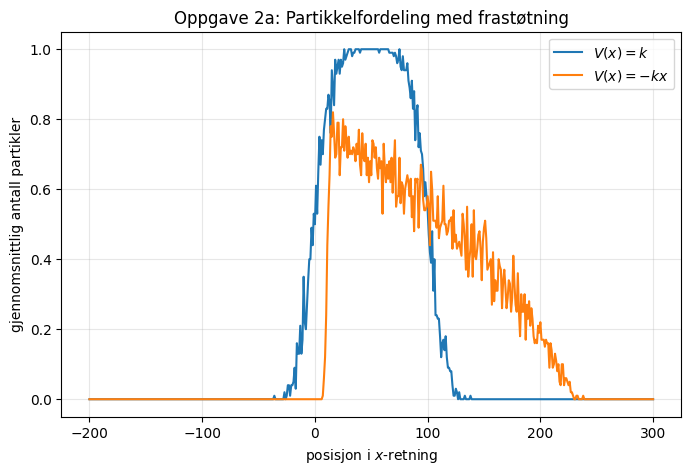

In [805]:
plot_oppgave_2_a_b(oppgave_2b, params_oppave_2, 
                  "Oppgave 2a: Partikkelfordeling med frastøtning")

Figuren viser hvordan partikler med frastøtning er gjennomsnittlig fordelt etter $100$ simulasjoner.

For potensial $V(x)=k$ er grafen fortsatt sentrert rundt $x = 50$ og tilnærmet symmetrisk. Rundt midtpunktet ser man at gjennomsnittet ligger helt flatt ved $1.0$ partikkel i gjennomsnitt. Dette tyder på at partiklene som ligger lengst unna ytterkantene av startkonfigurasjonen ikke får muligheten til å bevege seg etter kun $200$ timeSteps. Dette gir mening da de må vente til nabopartikkelen har flyttet seg, som igjen må vente til deres nabopartikkel har flyttet seg osv. Med for få timeSteps forventer man dermed at partikler i midten forblir uendret. Det er også et godt tegn at grafen ikke krysser over $1.0$ partikler i gjennomsnitt, da dette ville ha betydd at vi hadde hatt en feil i koden.

For potensial $V(x)= -kx$ ser grafen ut til å ha en tilnærmet lineær nedgang i gjennomsnittlig partikkelantall som x øker. Som man ser er det ingen partikler etter $200$ timeSteps som beveger seg forbi venstre startpunkt ved $x = 0$. Dette gir mening da sannsynligheten for at partikkelen lengst til venstre vil krysse dette punktet er svært liten ettersom $p_{\text{neg}} = 0.09$ og det krever at partikkelen tar flere steg til venstre enn høyre. Ved venstre side at grafen ser man også at snittet ligger på rundt $0.8$ partikler. Dette tyder på at patiklene lengst til venstre ikke får beveget seg så mye, som gir mening da de må vente til at alle partikler til høyre for seg har flyttet seg ettersom vi har frastøtning. Partikler som starter på høyre side vil ha flere muligheter til å flytte seg og flytte seg lenger, som er hvorfor gjennomsnittlig partikkeltetthet er lavere på høyre side. Man kan også observere at arealet under grafen er omtrent lik som i startposisjonen, som tyder på at masse er bevart og at simuleringen er riktig.

### Oppgave 2c)

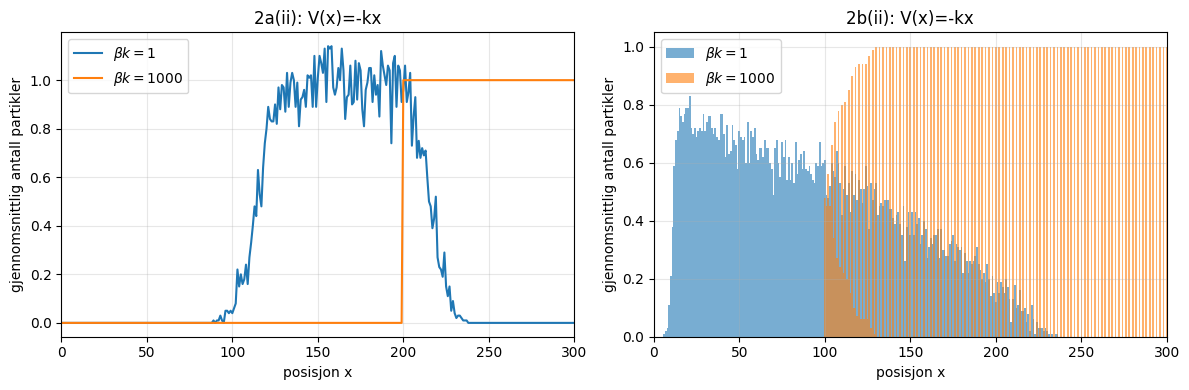

In [806]:
plot_2c(params_oppave_2)

Her har vi valgt å ikke plotte 2a(i) og 2b(i) ettersom de ikke avhenger av $\beta k$ og dermed vil plottet bli det samme som tidligere.

I figuren over har vi plottet 2a(ii) og 2b(ii) med $\beta k = 1$ og $\beta k = 1000$ for å sammenligne hvordan $\beta k$ påvirker den gjennomsnittlige partikkelfordelingen.

For 2a(ii) med $\beta k = 1000$ ser man at alle partiklene har beveget seg til høyre. Grunnen til dette er at ved $\beta k = 1000$ og $V(x) = -kx$ er $p_{\text{neg}} \approx 0$, $p_{0} \approx 0$ og $p_{\text{pos}} \approx 1$, slik at alle partiklene tilnærmet garantert beveger seg mot høyre dersom de har muligheten. Så etter $\text{timeSteps} = 200$ runder har alle partikler flyttet seg $200$ steg fra sin opprinnelige startposisjon som stemmer overens med at grafen ser ut til å gå til 1.0 ved x = 200. En sentral ting som gjør at dette skjer er at partiklene ikke påvirker hverandre, så alle partikler kan flytte seg uten å bli blokkert av noen andre. 

For 2b(ii) med $\beta k = 1000$ har også alle partikler flyttet seg til høyre, men her ser man at grafen starter på x = 100 og går bort til x = 300. Det man også observerer her er at det oppstår tomme posisjoner mellom toppene. En interessant ting man og kan se her er at fra omtrent rundt $x = 125$ havner partiklene ofte i samme posisjon i hver simulering, så når man tar gjennomsnittet får man disse piggene i posisjoner hvor partikler stopper, og tomrom mellom dem. Systemet blir dermed nesten deterministisk, og hvis $timeSteps$ hadde vært større ville vi ha bare sett disse piggene. 

Det er en matematisk grunn til hvorfor vi får dette resultatet. Vi velger å analysere dette litt nærmere da det er meget interessant. For å gjøre dette velger vi å nummerere partiklene fra høyre til venstre med partikkel 1 helt til høyre, partikkel 2 nest til høyre osv til partikkel 101 helt til venstre. Vi skal også her gjøre en antakelse om at $p_{\text{pos}} = 1$. La oss først se på partikkel 1, den vil dermed ta 200 steg mot høyre. Partikkel 2 vil også "kunne" ta 200 steg, men det krever at partikkel 1 alltid plukkes før partikkel 2 i rekkefølgen de skal flyttes i, noe som er svært usannsynlig ($\left(\frac{1}{2}\right)^{200}$). Så hvis man antar at partikkel 2 minst en gang plukkes før partikkel 1, vil det etter den flytterunden bli et mellomrom mellom dem. Etter dette vil dette mellomrommet forbli gjennom resten av simuleringen ettersom partikkel 2 dermed alltid vil ha muligheten til å flytte høyre. Dette resulterer i at partikkel 2 får garantert minst 199 steg totalt i en simulering, altså mister partikkel 2 maks ett steg. Vi antar så en worst case og sier at partikkel 2 får 199 steg i en simulering. Dermed kan vi bruke samme logikken mellom partikkel 2 og partikkel 3. Ettersom vi er i worst case kan vi dermed si at partikkel 3 kun får 199 runder til å flytte seg, og at partikkel 2 flytter seg garantert i hver slik runde. Ved samme logikk som istad vil dermed partikkel 3 få minst 198 steg og maks miste 2 steg. Rekursivt kan man fortsette slik ned til partikkel 101 som dermed vil få garantert minst 100 steg. Alternativt kan man også komme fram til samme konklusjon ved å si at i worst-case så flyttes partiklene alltid fra venstre til høyre, som også gir minst 100 steg for partikkel 101. Dette samsvarer godt med det vi observerer i grafen. Man kan også legge merke til at fra $x = 100$ til rundt $x = 125$ har grafen ikke samme tomrom som man observerer fra rundt $x = 125$ og utover. Grunnen til dette er fordi antakelsen om at eksempelvis partikkel 101 bare kan flytte seg i runder når partikkel 100 kan flytte seg, blir for enkel. Det som i praksis kan skje her er at partikkel 101 kan "ta igjen" partikkel 100 og tette tomrommet mellom dem (partikkel 101 får tilnærmet $99$ muligheter til å bli nabo med partikkel 100 igjen dersom de ikke allerede er det ettersom partikkel 100 kan miste maks $99$ steg). Hvis dermed partikkel 100 blir valgt før 101 i siste runde vil de ende opp som naboer. Så i de tilfeller partiklene ender opp som naboer etter en simulering, gir det et bidrag på gjennomsnittlig antall partikler i hver posisjon og "tetter" igjen mellomrommene i plottet.